Load and Prepare Stock Price Data

In this step, we load our stock price dataset (OHLCV data) into a Pandas DataFrame.

The dataset must contain at least the following columns:

- **Open** — Opening price  
- **High** — Highest price of the day  
- **Low** — Lowest price  
- **Close** — Closing price  
- **Volume** — Number of shares traded  
- **Adj Close** — Adjusted closing price (optional but useful)

After loading:

1. Convert the `Date` column to datetime format  
2. Sort the data by date  
3. Set the date column as the index  
4. Inspect the first few rows  

This prepares clean data for technical indicator calculations (SMA, EMA, RSI, MACD) in later steps.


In [45]:
import pandas as pd
from pathlib import Path

# Path to your stock price folder
data_path = Path("../Data/yfinance_data/Data")

# List all CSVs inside the folder
csv_files = list(data_path.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError("No CSV files found in Data/yfinance_data_Data/. Please add stock price CSVs.")

# Prefer AAPL.csv if it exists, otherwise take the first file
sample_csv = data_path / "AAPL.csv" if (data_path / "AAPL.csv").exists() else csv_files[0]

print("Loading:", sample_csv.name)

# Load into pandas DataFrame
df = pd.read_csv(sample_csv, parse_dates=["Date"])

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Sort & set index
df = df.sort_values("date")
df = df.set_index("date")

# Show sample rows
df.head()


Loading: AAPL.csv


,close,high,low,open,volume
date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


## Validate Required OHLCV Columns

Before proceeding to technical analysis, we must verify that the dataset contains:

- open  
- high  
- low  
- close  
- volume  

If any required columns are missing, the notebook will warn you.


In [46]:
required_cols = ["open", "high", "low", "close", "volume"]

for col in required_cols:
    if col not in df.columns:
        print(f"WARNING: Missing column: {col.upper()}")
    else:
        print(f"Column found: {col.upper()}")


Column found: OPEN
Column found: HIGH
Column found: LOW
Column found: CLOSE
Column found: VOLUME


## Create Daily Returns Column

Daily returns help us compute:

- volatility  
- annualized return  
- Sharpe ratio  
- correlation with news sentiment (later)

Formula used:

\[
\text{Daily Return} = \frac{\text{Adj Close}_t - \text{Adj Close}_{t-1}}{\text{Adj Close}_{t-1}}
\]

If `Adj Close` does not exist, we fallback to `Close`.


In [47]:
if "adj close" in df.columns:
    df["daily_return"] = df["adj close"].pct_change()
else:
    df["daily_return"] = df["close"].pct_change()

df.head()


,close,high,low,open,volume,daily_return
date,,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,0.042204
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,-0.016494
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,-0.021609
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,0.018570


## Summary of Prepared Data

Now we inspect:

- DataFrame shape  
- Date range  
- Basic statistics  
- Missing values  

This ensures the dataset is clean before computing indicators.


In [48]:
print("Shape:", df.shape)
print("\nDate Range:", df.index.min(), "→", df.index.max())

print("\nMissing Values:")
print(df.isna().sum())

print("\nDescriptive Statistics:")
df.describe()


Shape: (3774, 6)

Date Range: 2009-01-02 00:00:00 → 2023-12-29 00:00:00

Missing Values:
close           0
high            0
low             0
open            0
volume          0
daily_return    1
dtype: int64

Descriptive Statistics:


,close,high,low,open,volume,daily_return
count,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03,3773.000000
mean,53.841169,54.383801,53.247465,53.801628,2.640640e+08,0.001289
std,55.064042,55.627235,54.440128,55.009182,2.345629e+08,0.018010
min,2.345299,2.459265,2.345299,2.380989,2.404830e+07,-0.128647
25%,15.050355,15.183043,14.901886,15.007580,9.581845e+07,-0.007547
50%,26.975808,27.168844,26.836844,27.010205,1.667348e+08,0.001062
75%,74.664204,75.252383,73.553555,74.127927,3.777410e+08,0.010770
max,196.256592,197.752460,195.156944,196.167437,1.880998e+09,0.119808


## Compute Technical Indicators

Compute:
- SMA(20), EMA(20)
- RSI(14)
- MACD (12,26,9) and MACD signal/hist if available

Attempt to use TA-Lib (if installed). If not available, we fall back to `pandas_ta`.  
Indicators are saved to `results_task2/indicators_<TICKER>.csv`.


In [49]:
# Compute indicators (TA-Lib preferred, pandas_ta fallback)
from pathlib import Path
import numpy as np


# assumes `df` exists and is indexed by datetime (date index) and has 'close', 'open', 'high', 'low', 'volume'
use_talib = False
try:
    import talib
    use_talib = True
    print("Using TA-Lib for indicators.")
except Exception as e:
    print("TA-Lib not available:", e)

# attempt pandas_ta
try:
    import pandas_ta as pta
    print("pandas_ta loaded (will use if TA-Lib not available).")
except Exception as e:
    pta = None
    print("pandas_ta not available:", e)

# compute indicators into df_ind
df_ind = df.copy()

if use_talib:
    import talib as ta
    close = df_ind['close'].astype(float).values
    df_ind['sma_20'] = ta.SMA(close, timeperiod=20)
    df_ind['ema_20'] = ta.EMA(close, timeperiod=20)
    df_ind['rsi_14'] = ta.RSI(close, timeperiod=14)
    macd, macd_signal, macd_hist = ta.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
    df_ind['macd'] = macd
    df_ind['macd_signal'] = macd_signal
    df_ind['macd_hist'] = macd_hist
else:
    if pta is None:
        raise ImportError("Please install pandas_ta (pip) or TA-Lib (system deps + pip) to compute indicators.")
    # pandas_ta returns series/DataFrame; ensure column names consistent
    df_ind['sma_20'] = pta.sma(df_ind['close'], length=20)
    df_ind['ema_20'] = pta.ema(df_ind['close'], length=20)
    df_ind['rsi_14'] = pta.rsi(df_ind['close'], length=14)
    macd_df = pta.macd(df_ind['close'], fast=12, slow=26, signal=9)
    # macd_df columns might be named like MACD_12_26_9, MACDs_12_26_9, MACDh_12_26_9
    # normalize names
    macd_df = macd_df.rename(columns=lambda c: c.lower().replace("macd_", "macd_").replace("macds_", "macd_signal_").replace("macdh_", "macd_hist_"))
    # add to df_ind
    for col in macd_df.columns:
        df_ind[col] = macd_df[col]

# Quick check
display(df_ind[['close','sma_20','ema_20','rsi_14']].tail(8))



Using TA-Lib for indicators.
pandas_ta not available: Numba needs NumPy 2.2 or less. Got NumPy 2.3.


,close,sma_20,ema_20,rsi_14
date,,,,
2023-12-19,195.097504,191.302353,191.159955,64.544428
2023-12-20,193.007248,191.509893,191.335888,58.247457
2023-12-21,192.858643,191.676816,191.480912,57.815603
2023-12-22,191.788757,191.856618,191.510231,54.672784
2023-12-26,191.243912,192.018094,191.484867,53.090049
2023-12-27,191.342972,192.154308,191.471353,53.354446
2023-12-28,191.768951,192.362839,191.499696,54.540999
2023-12-29,190.728775,192.490633,191.426275,51.121347


## Financial Metrics

Compute:
- Annualized return
- Annualized volatility
- Sharpe ratio (annualized)
- Maximum drawdown
- Simple signal performance (directional accuracy)

If `pynance` is available we'll use it; otherwise compute metrics manually from daily returns.


In [50]:
# Financial metrics (PyNance optional)
import numpy as np
import pandas as pd
from math import isnan

use_pynance = False
try:
    import pynance as pn
    use_pynance = True
    print("pynance available.")
except Exception as e:
    print("pynance not available:", e)

# use df_ind['daily_return'] computed earlier, otherwise compute from adj close or close
if 'daily_return' not in df_ind.columns:
    if 'adj close' in df_ind.columns:
        df_ind['daily_return'] = df_ind['adj close'].pct_change()
    else:
        df_ind['daily_return'] = df_ind['close'].pct_change()

rets = df_ind['daily_return'].dropna()
n = len(rets)

# Annualized return and volatility (assume 252 trading days)
if n == 0:
    raise ValueError("No returns available to compute metrics.")
ann_return = (1 + rets.mean())**252 - 1
ann_vol = rets.std() * np.sqrt(252)
sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

# Max drawdown
cum = (1 + rets).cumprod()
running_max = cum.cummax()
drawdown = (cum / running_max) - 1
max_drawdown = drawdown.min()

metrics = {
    'observations': n,
    'annualized_return': ann_return,
    'annualized_volatility': ann_vol,
    'sharpe_ratio': sharpe,
    'max_drawdown': max_drawdown
}

# Just display metrics instead of saving
metrics_df = pd.DataFrame([metrics])
display(metrics_df)


pynance not available: No module named 'pynance'


,observations,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown
0,3773,0.383541,0.285902,1.341515,-0.437971


## Simple signals & evaluation

Create simple signals as examples:
- SMA crossover rule (short example): signal = 1 when close > sma_20 (long), -1 when close < sma_20 (short)
- RSI threshold: oversold (RSI < 30) buy signal, overbought (RSI > 70) sell signal.

Compute directional accuracy for next-day returns as a basic evaluation:
- Predict sign(next-day return) using today's signal.


In [51]:
# Signals
sig_df = df_ind.copy().dropna(subset=['close'])

# SMA rule
if 'sma_20' in sig_df.columns:
    sig_df['sig_sma'] = 0
    sig_df.loc[sig_df['close'] > sig_df['sma_20'], 'sig_sma'] = 1
    sig_df.loc[sig_df['close'] < sig_df['sma_20'], 'sig_sma'] = -1

# RSI rule
if 'rsi_14' in sig_df.columns:
    sig_df['sig_rsi'] = 0
    sig_df.loc[sig_df['rsi_14'] < 30, 'sig_rsi'] = 1
    sig_df.loc[sig_df['rsi_14'] > 70, 'sig_rsi'] = -1

# Next-day returns: shift daily_return by -1 so signal today predicts next day
sig_df['next_return'] = sig_df['daily_return'].shift(-1)

def directional_accuracy(signal_col):
    df_eval = sig_df.dropna(subset=[signal_col,'next_return'])
    if len(df_eval) == 0:
        return None
    preds = df_eval[signal_col]
    actual_sign = np.sign(df_eval['next_return'])
    # Replace zeros in actual_sign with 0
    match = (np.sign(preds) == actual_sign)
    acc = match.mean()
    # directional precision for predicted long (1)
    long_mask = preds == 1
    short_mask = preds == -1
    long_acc = (np.sign(df_eval.loc[long_mask,'next_return']) == 1).mean() if long_mask.any() else np.nan
    short_acc = (np.sign(df_eval.loc[short_mask,'next_return']) == -1).mean() if short_mask.any() else np.nan
    return {'accuracy': acc, 'n': len(df_eval), 'long_acc': long_acc, 'short_acc': short_acc}

results = {}
if 'sig_sma' in sig_df.columns:
    results['sma'] = directional_accuracy('sig_sma')
if 'sig_rsi' in sig_df.columns:
    results['rsi'] = directional_accuracy('sig_rsi')

pd.DataFrame(results).T


,accuracy,n,long_acc,short_acc
sma,0.519215,3773.0,0.542209,0.485798
rsi,0.080042,3773.0,0.617647,0.440767


## Visualizations

Create and save:
- Price with SMA(20) and EMA(20)
- RSI chart with 70/30 thresholds
- MACD and MACD signal
- Histogram of daily returns
All saved in `results_task2/`.


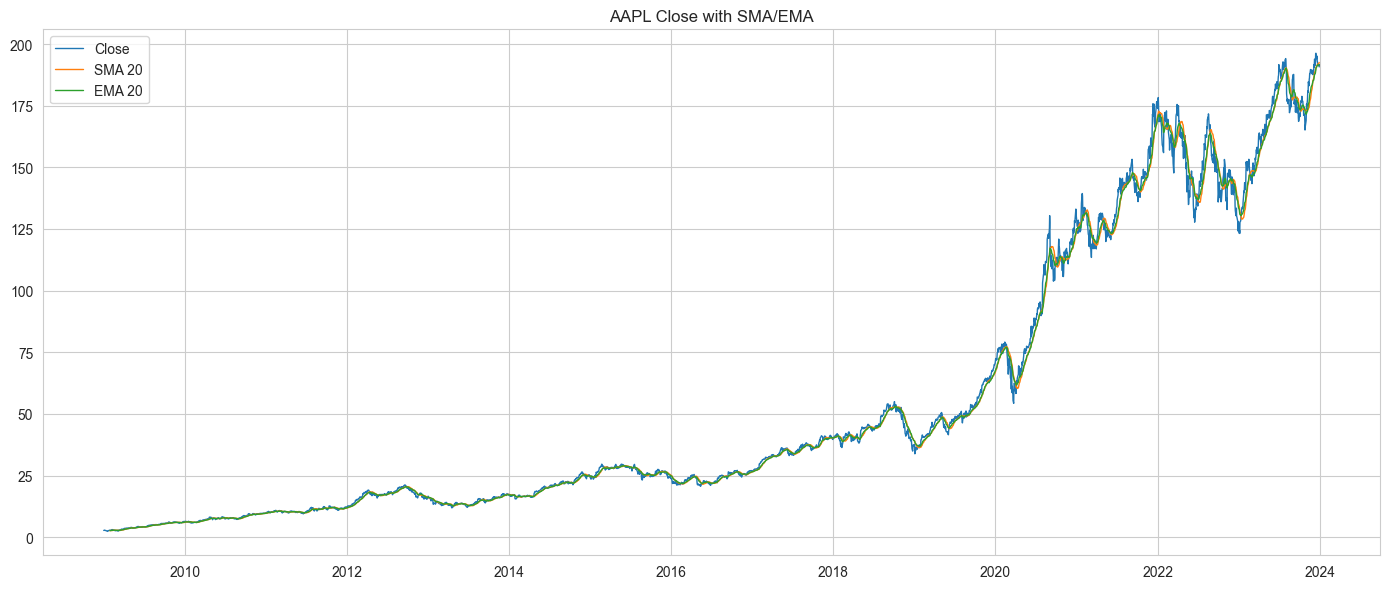

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

ticker = "AAPL"   # <-- define your ticker here
out = RESULTS

# Price + SMA/EMA
plt.figure(figsize=(14,6))
plt.plot(df_ind.index, df_ind['close'], label='Close', linewidth=1)
if 'sma_20' in df_ind.columns:
    plt.plot(df_ind.index, df_ind['sma_20'], label='SMA 20', linewidth=1)
if 'ema_20' in df_ind.columns:
    plt.plot(df_ind.index, df_ind['ema_20'], label='EMA 20', linewidth=1)
plt.legend()
plt.title(f"{ticker} Close with SMA/EMA")
plt.tight_layout()

plt.show()
